In [1]:
import pandas as pd
from cdc_ml.config import POLLS_PROCESSED, CUSTOMER_CLASS_PROCESSED
from cdc_ml.features.build_features import assign_class_type,get_whale_users
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

2026-06-09 12:29:00.592 | INFO     | cdc_ml.config:<module>:12 - PROJ_ROOT path is: C:\Users\zhiju\Desktop\cdc_ml


In [2]:
df = pd.read_parquet(POLLS_PROCESSED)
df_class = pd.read_parquet(CUSTOMER_CLASS_PROCESSED)
df = assign_class_type(df,df_class)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29612 entries, 0 to 29611
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype                         
---  ------             --------------  -----                         
 0   id                 29612 non-null  int64                         
 1   username           29612 non-null  str                           
 2   cycle_start        29612 non-null  datetime64[us, Asia/Singapore]
 3   cycle_end          29612 non-null  datetime64[us, Asia/Singapore]
 4   polling_at         29612 non-null  datetime64[us, Asia/Singapore]
 5   has_booking        29612 non-null  bool                          
 6   cycle_start_month  29612 non-null  int32                         
 7   cycle_start_day    29612 non-null  int32                         
 8   cycle_start_dow    29612 non-null  int32                         
 9   cycle_start_hour   29612 non-null  int32                         
 10  polling_month      29612 non-null  int32     

In [43]:
df = df.sort_values(by="polling_at")
df.loc[df["username"]=="matt"]

,id,username,cycle_start,cycle_end,polling_at,has_booking,cycle_start_month,cycle_start_day,cycle_start_dow,cycle_start_hour,polling_month,polling_day,polling_dow,polling_hour,hours_into_cycle,class_type,is_one_team
1121,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-12 01:00:00+08:00,False,8,12,1,1,8,12,1,1,-0.35,1,1
1122,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-12 02:00:00+08:00,False,8,12,1,1,8,12,1,2,0.65,1,1
1123,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-12 03:00:00+08:00,False,8,12,1,1,8,12,1,3,1.65,1,1
1124,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-12 04:00:00+08:00,False,8,12,1,1,8,12,1,4,2.65,1,1
1125,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-12 05:00:00+08:00,False,8,12,1,1,8,12,1,5,3.65,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2689,7,matt,2025-10-07 23:00:00+08:00,2025-10-30 12:00:00+08:00,2025-10-30 08:00:00+08:00,False,10,7,1,23,10,30,3,8,537.00,1,1
2690,7,matt,2025-10-07 23:00:00+08:00,2025-10-30 12:00:00+08:00,2025-10-30 09:00:00+08:00,False,10,7,1,23,10,30,3,9,538.00,1,1
2691,7,matt,2025-10-07 23:00:00+08:00,2025-10-30 12:00:00+08:00,2025-10-30 10:00:00+08:00,False,10,7,1,23,10,30,3,10,539.00,1,1
2692,7,matt,2025-10-07 23:00:00+08:00,2025-10-30 12:00:00+08:00,2025-10-30 11:00:00+08:00,False,10,7,1,23,10,30,3,11,540.00,1,1


In [5]:
has_booking_counts = df["has_booking"].value_counts()
has_booking_share = df["has_booking"].value_counts(normalize=True)

has_booking_stats = pd.concat([has_booking_counts, has_booking_share], axis=1)
has_booking_stats.columns = ["count", "share"]

In [6]:
has_booking_stats

,count,share
has_booking,,
False,29222,0.98683
True,390,0.01317


In [7]:
def eda_label_rate(x):
    label_rate = (
        df.groupby(x)["has_booking"]
        .agg(share="mean", count="count")
        .reset_index()
    )
    fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    base = df["has_booking"].mean()

    # Top: label rate with 95% CI

    sns.barplot(data=df, x=x, y="has_booking", ax=axes[0], errorbar=("ci", 95))
    axes[0].axhline(base, color="red", linestyle="--", label=f"base rate ({base:.3f})")
    axes[0].set_ylabel("P(has_booking)")

    # Bottom: exposure per category
    sns.barplot(data=label_rate, x=x, y="count", ax=axes[1], color="steelblue")
    axes[1].set_ylabel("n observations")

    plt.tight_layout()


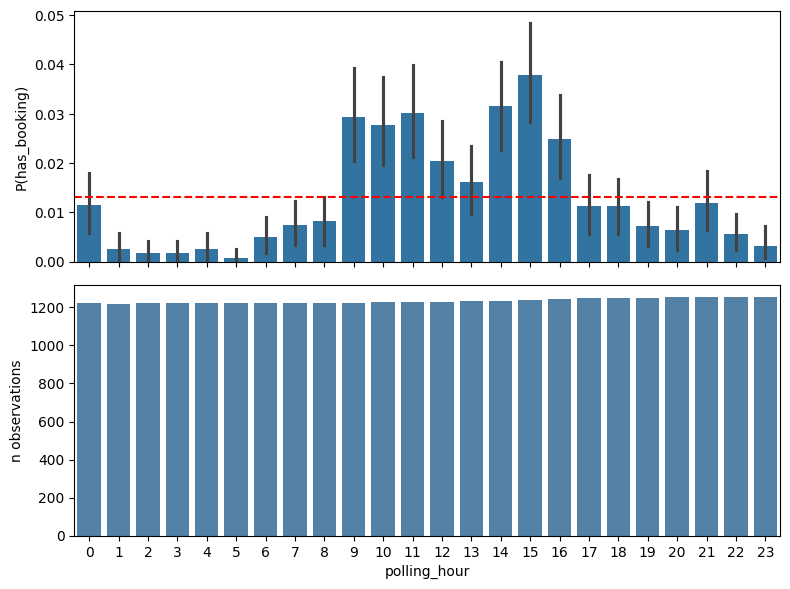

In [8]:
eda_label_rate("polling_hour")

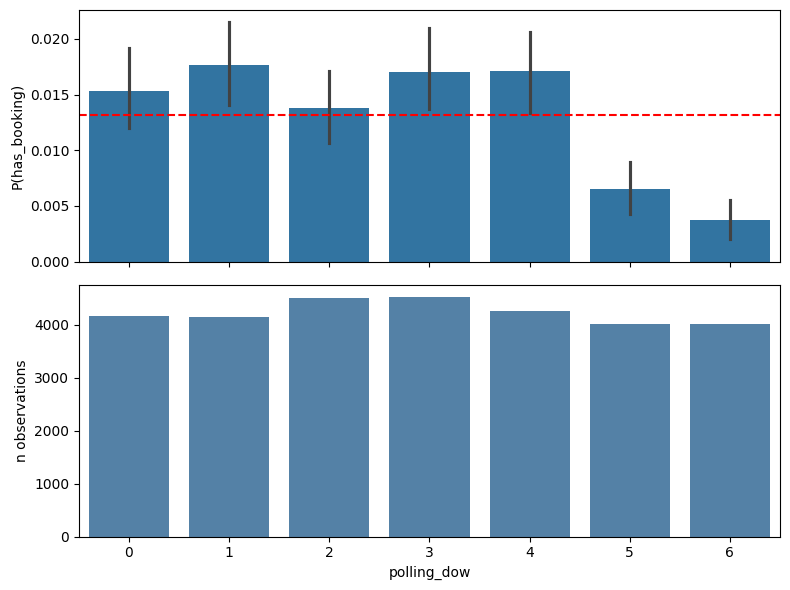

In [9]:
eda_label_rate("polling_dow")

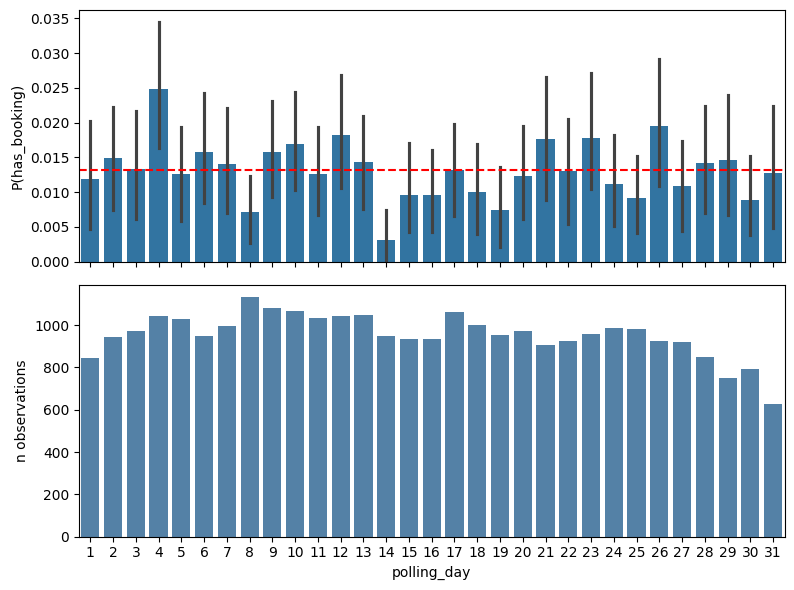

In [10]:
eda_label_rate("polling_day")

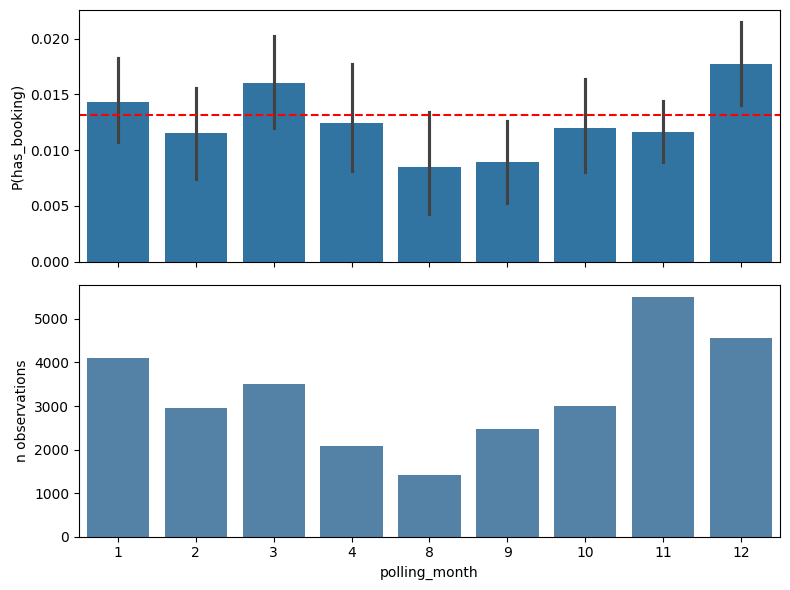

In [11]:
label_rate_by_polling_month = eda_label_rate("polling_month")

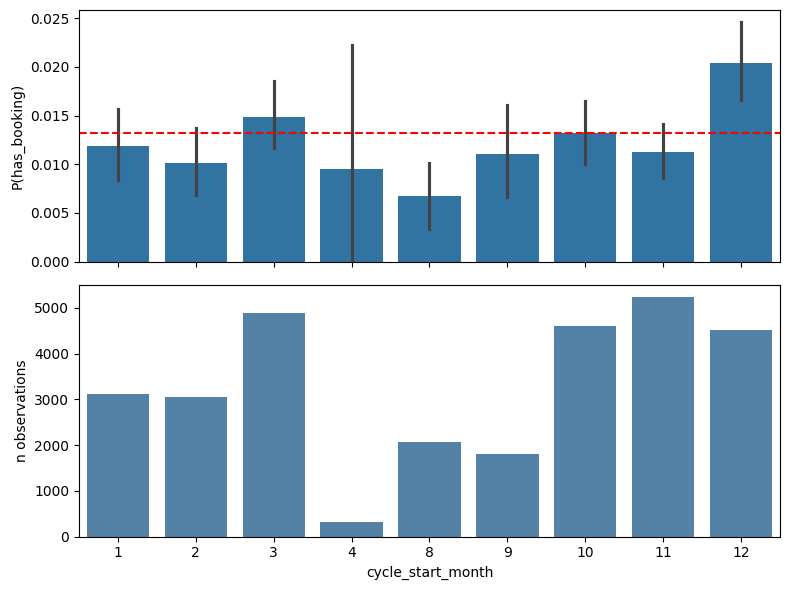

In [12]:
eda_label_rate("cycle_start_month")

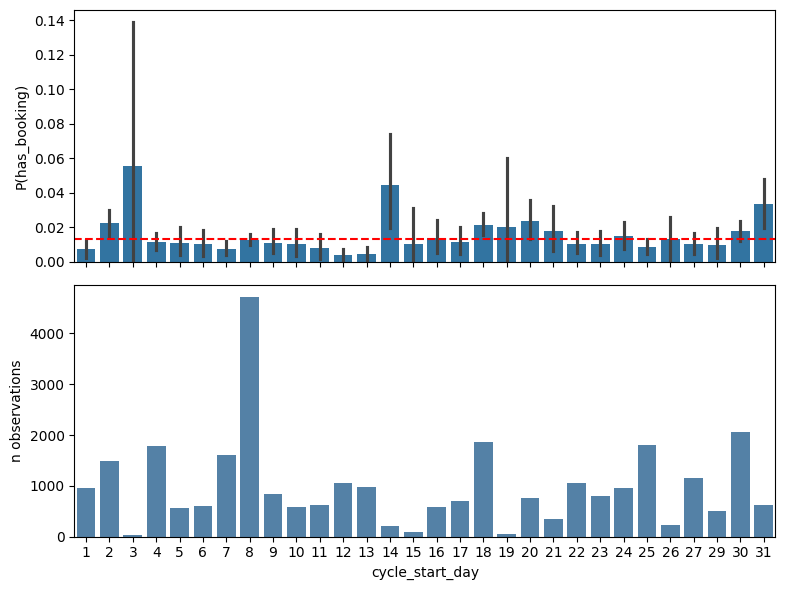

In [13]:
eda_label_rate("cycle_start_day")

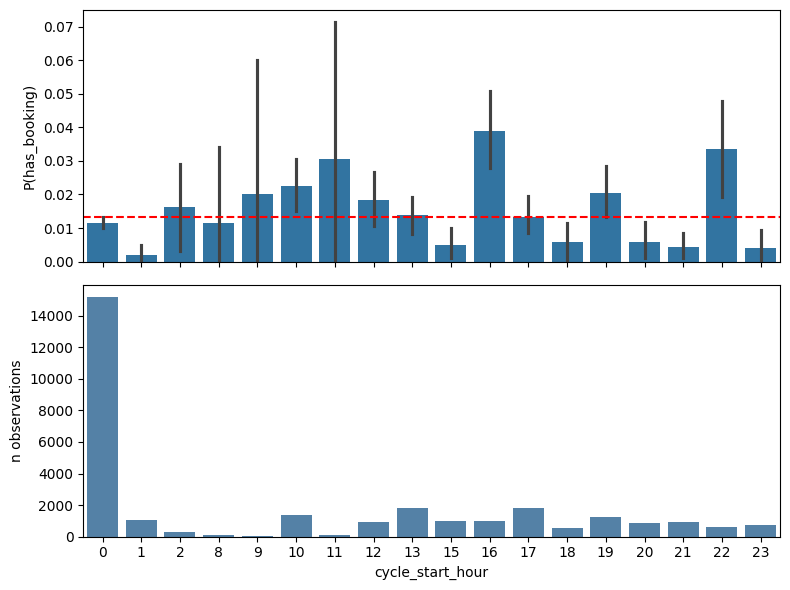

In [14]:
eda_label_rate("cycle_start_hour")

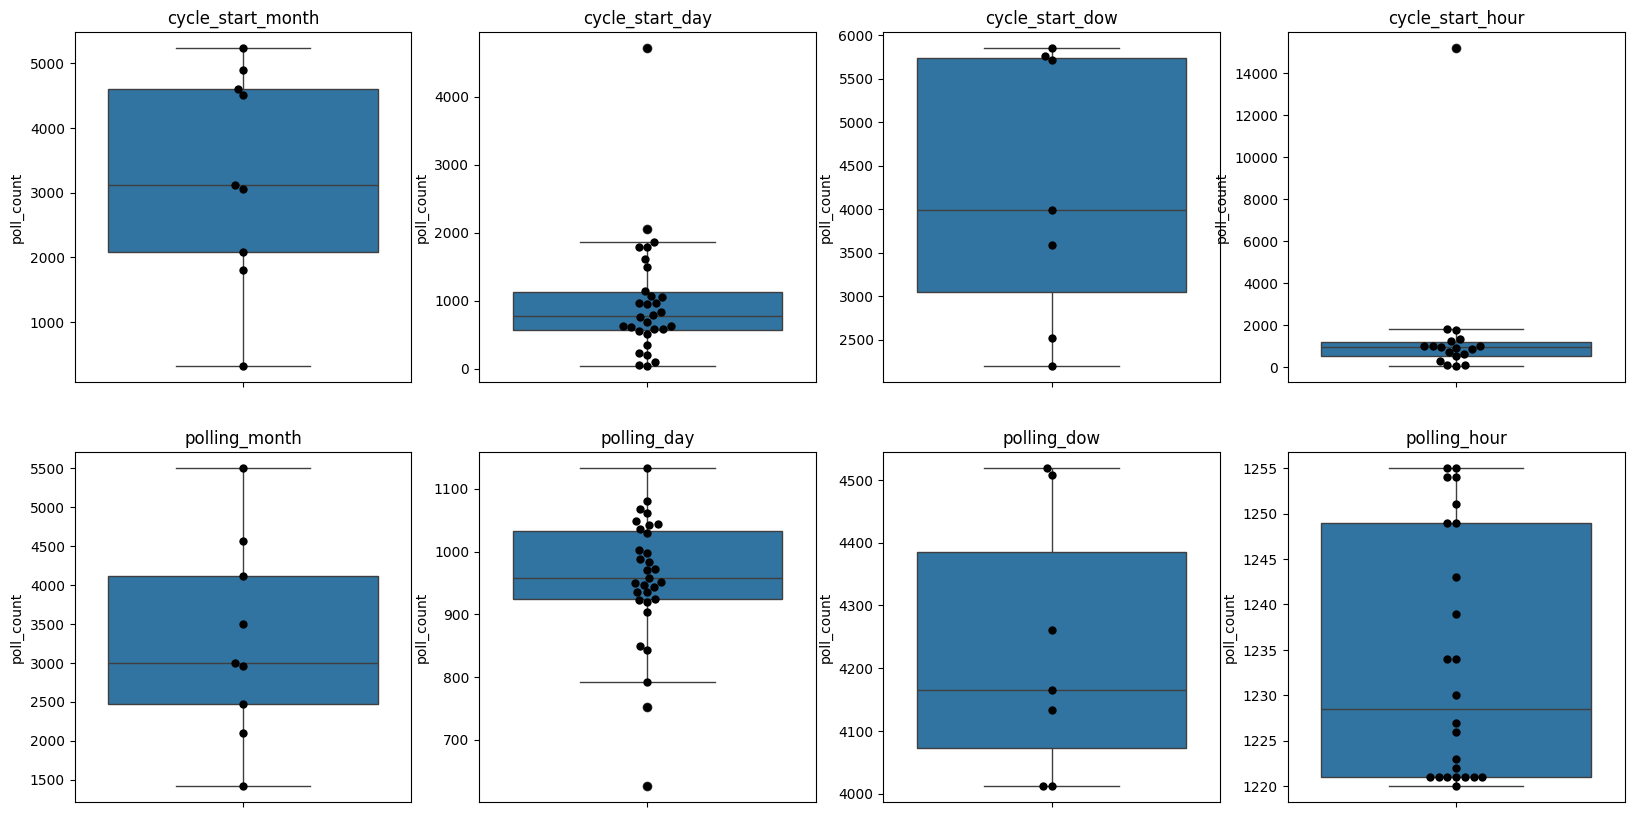

In [15]:
fig,axes = plt.subplots(2,4,figsize=(20,10))

plot_lists = [["cycle_start_month","cycle_start_day","cycle_start_dow","cycle_start_hour",],
              ["polling_month","polling_day","polling_dow","polling_hour"]
              ]

for i in range(2):
    for j in range(4):
        current = plot_lists[i][j]
        count = df.groupby(current)["username"].count().reset_index(name="poll_count")
        sns.boxplot(y=count["poll_count"],ax=axes[i][j])
        sns.swarmplot(y=count["poll_count"], color="black", size=6,ax=axes[i][j])
        axes[i][j].set_title(current)  

In [16]:
def cramers_v(df, x, y):
    ct = pd.crosstab(df[x], df[y])
    chi2, p, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    k = min(ct.shape) - 1                       # df_min — drives the thresholds
    v = np.sqrt(chi2 / (n * k))

    small, medium, large = (c / np.sqrt(k) for c in (0.10, 0.30, 0.50))
    if   v >= large:  label = "large"
    elif v >= medium: label = "medium"
    elif v >= small:  label = "small"
    else:             label = "negligible / no association"

    print(f"χ²={chi2:.1f}  p={p:.2e}  V={v:.3f}  (df={k})  → {label}")
    return v, p


In [17]:
cramers_v(df,"cycle_start_month","polling_month")

χ²=145350.9  p=0.00e+00  V=0.783  (df=8)  → large


(np.float64(0.7833034250128832), np.float64(0.0))

In [18]:
cramers_v(df,"cycle_start_day","polling_day")

χ²=31936.4  p=0.00e+00  V=0.193  (df=29)  → large


(np.float64(0.19284562880375147), np.float64(0.0))

In [19]:
cramers_v(df,"cycle_start_hour","polling_hour")

χ²=27.1  p=1.00e+00  V=0.007  (df=17)  → negligible / no association


(np.float64(0.0073336855862738415), np.float64(1.0))

In [20]:

cramers_v(df,"polling_month","polling_day")

χ²=6501.4  p=0.00e+00  V=0.166  (df=8)  → medium


(np.float64(0.16566229166242086), np.float64(0.0))

In [21]:
cramers_v(df,"polling_day","polling_dow")

χ²=11637.7  p=0.00e+00  V=0.256  (df=6)  → large


(np.float64(0.2559318470836812), np.float64(0.0))

In [22]:
cramers_v(df,"polling_dow","polling_hour")

χ²=2.6  p=1.00e+00  V=0.004  (df=6)  → negligible / no association


(np.float64(0.0038535184344633245), np.float64(1.0))

In [23]:
cramers_v(df,"polling_dow","has_booking")

χ²=59.7  p=5.20e-11  V=0.045  (df=1)  → negligible / no association


(np.float64(0.04489674484546926), np.float64(5.204658396591905e-11))

In [24]:

cramers_v(df,"polling_hour","has_booking")

χ²=278.8  p=8.44e-46  V=0.097  (df=1)  → negligible / no association


(np.float64(0.0970365514495631), np.float64(8.441709287459462e-46))

   username  has_booking
32    anaya         1728
33       jy         1786
34   flower         2001
35    anmol         2042
36      kim         3816


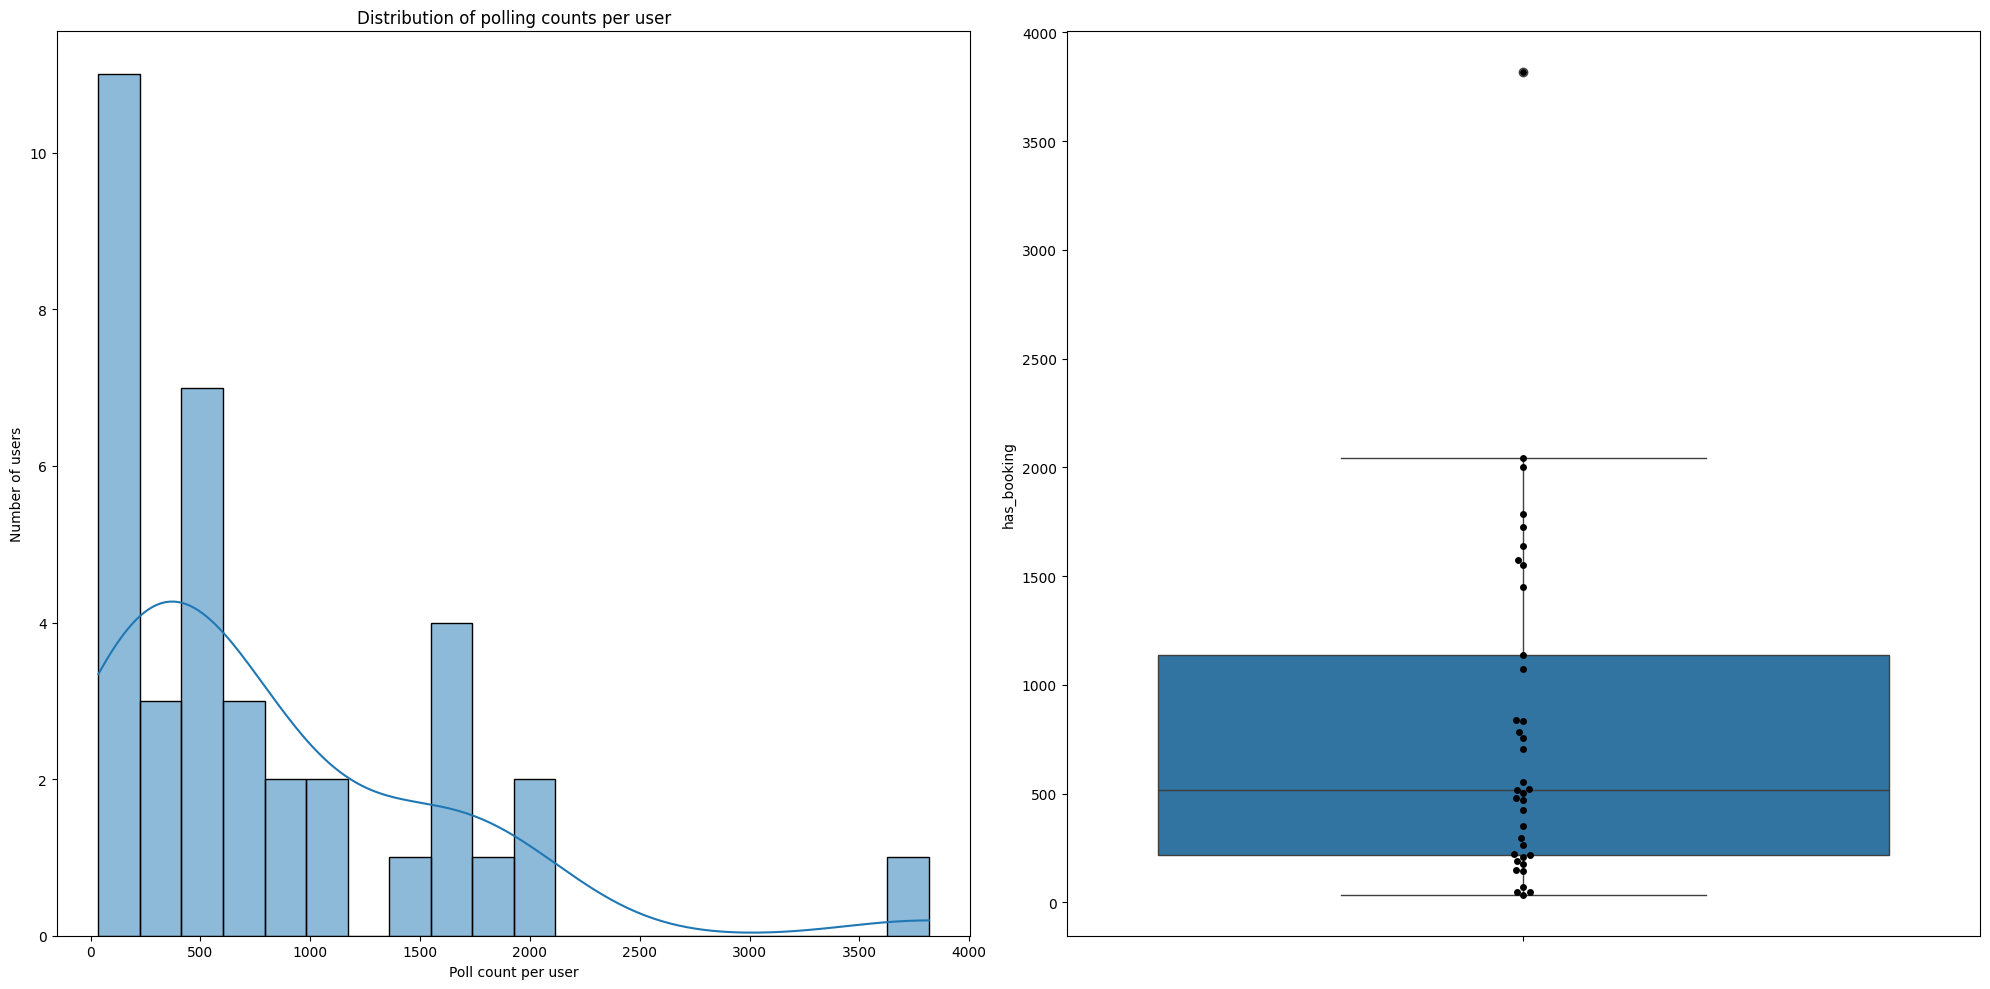

In [25]:
user_distribution = df.groupby("username")["has_booking"].count().sort_values().reset_index()
print(user_distribution.tail())

fig, axes = plt.subplots(1,2,figsize=(20, 10))
sns.histplot(
    data=user_distribution,
    x="has_booking",
    bins=20,
    kde=True,      
    ax=axes[0]
)
axes[0].set_xlabel("Poll count per user")
axes[0].set_ylabel("Number of users")
axes[0].set_title("Distribution of polling counts per user")

sns.boxplot(data=user_distribution,y="has_booking",ax=axes[1])
sns.swarmplot(data=user_distribution,y="has_booking",color="black",ax=axes[1])
plt.tight_layout()
plt.show()

In [26]:
count = df.groupby(["username"])["has_booking"].count().reset_index()
q_25,q_50,q_75 = count["has_booking"].quantile([0.25,0.5,0.75])

iqr = q_75 - q_25
print(q_25,q_50,q_75,iqr)

216.0 516.0 1139.0 923.0


<Axes: xlabel='poll_count', ylabel='booking_rate'>

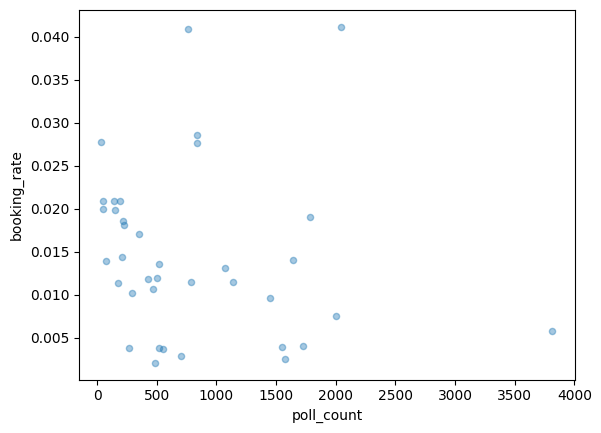

In [27]:
stats = df.groupby("username")["has_booking"].agg(["count", "mean"]).reset_index()
stats.columns = ["username", "poll_count", "booking_rate"]

# Does booking rate correlate with how long they've been observed?
stats.plot.scatter(x="poll_count", y="booking_rate", alpha=0.4)

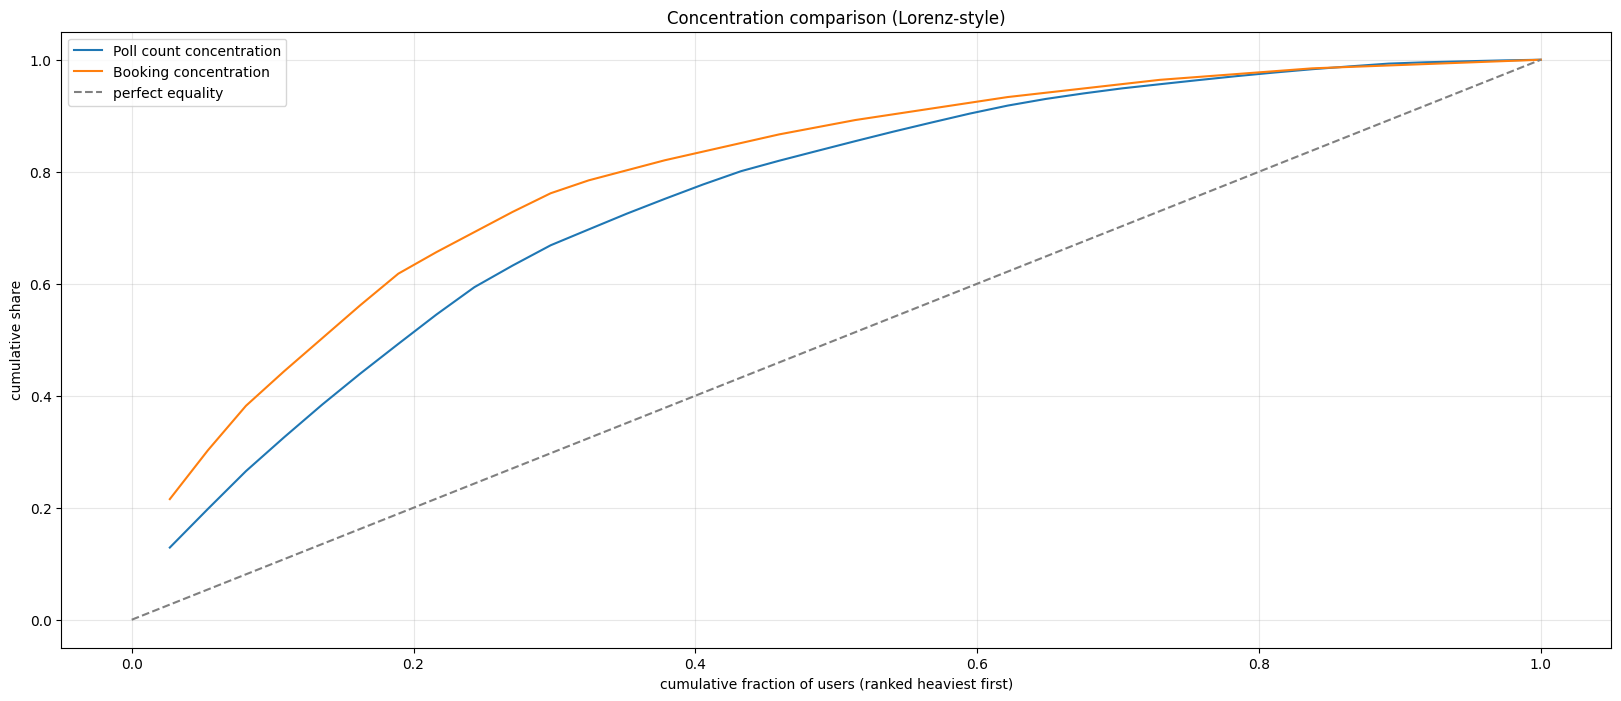

In [28]:
fig, ax = plt.subplots(figsize=(20, 8))

# --- 1) Poll count Lorenz curve ---
counts = (
    df['username']
    .value_counts()
    .reset_index(name='count')
)
counts['share'] = counts['count'] / counts['count'].sum()

counts = counts.sort_values('share', ascending=False).reset_index(drop=True)
counts['cum_share'] = counts['share'].cumsum()
counts['cum_frac'] = (counts.index + 1) / len(counts)

ax.plot(
    counts['cum_frac'],
    counts['cum_share'],
    label='Poll count concentration'
)

# --- 2) Booking Lorenz curve ---
total_sum = df["has_booking"].sum()

bookings = (
    df.groupby("username")["has_booking"]
    .sum()
    .sort_values(ascending=False)
    .reset_index(name='sum')
)

bookings['share'] = bookings['sum'] / total_sum
bookings['cum_share'] = bookings['share'].cumsum()
bookings['cum_frac'] = (bookings.index + 1) / len(bookings)

ax.plot(
    bookings['cum_frac'],
    bookings['cum_share'],
    label='Booking concentration'
)

# --- equality line ---
ax.plot([0, 1], [0, 1], '--', color='gray', label='perfect equality')

# formatting
ax.set_xlabel('cumulative fraction of users (ranked heaviest first)')
ax.set_ylabel('cumulative share')
ax.set_title('Concentration comparison (Lorenz-style)')
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()


JS divergence (positive-location): 0.322   # 0 = identical pattern, 1 = disjoint


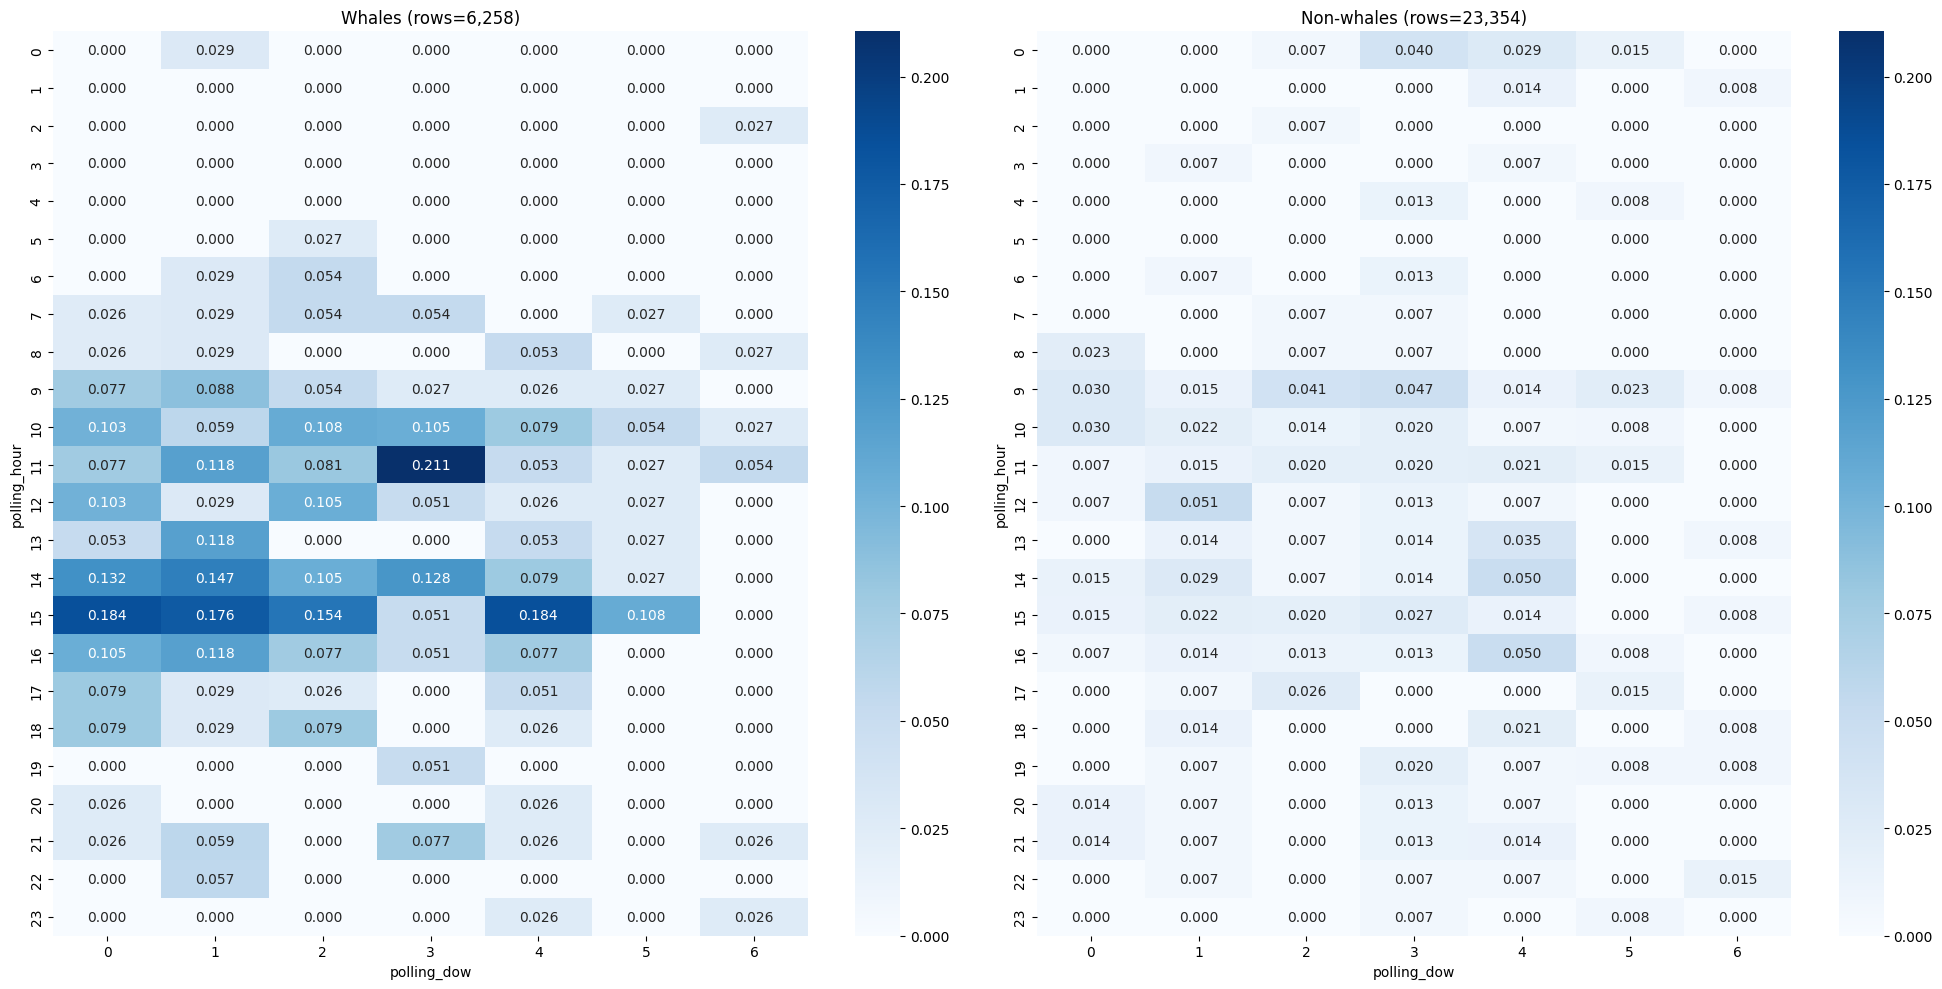

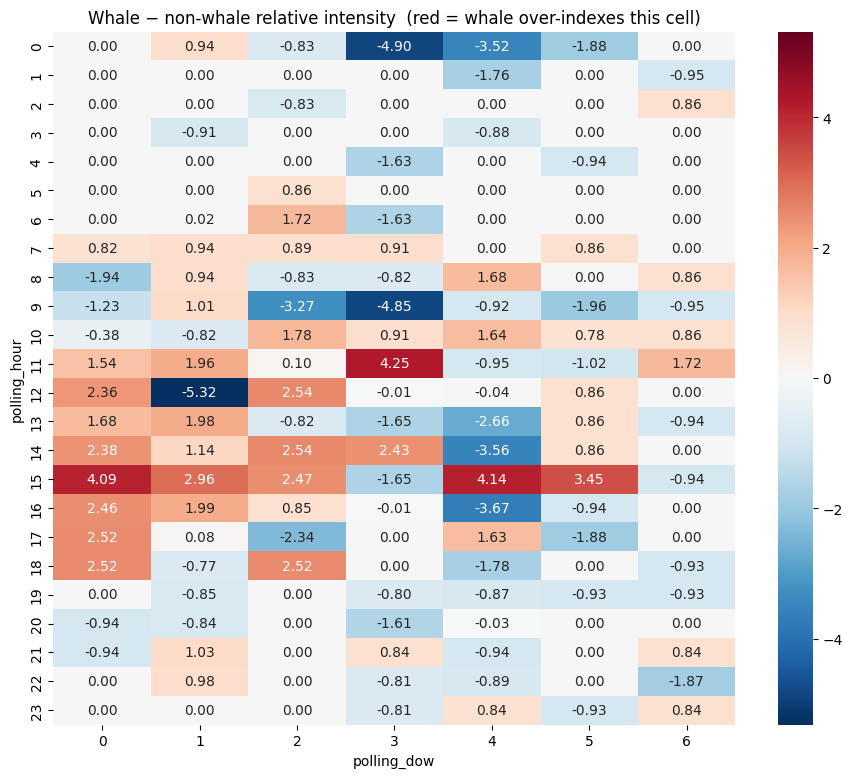

In [29]:
whales_pc,whales_pt = get_whale_users()
is_whale = df["username"].isin(whales_pt)

# Full grid so BOTH heatmaps share identical axes (missing cells -> NaN, not dropped/misaligned)
dows  = sorted(df["polling_dow"].unique())
hours = sorted(df["polling_hour"].unique())

def grid(sub):
    g = sub.groupby(["polling_dow", "polling_hour"])["has_booking"]
    rate    = g.mean().unstack("polling_dow").reindex(index=hours, columns=dows)
    support = g.size().unstack("polling_dow").reindex(index=hours, columns=dows)
    return rate, support

w_rate,  w_support  = grid(df[is_whale])
nw_rate, nw_support = grid(df[~is_whale])

MIN_POLLS = 30
w_rate_m  = w_rate.mask(w_support  < MIN_POLLS)
nw_rate_m = nw_rate.mask(nw_support < MIN_POLLS)

# --- FIX 1: shared color scale, so the side-by-side is honest about LEVEL ---
vmax = float(np.nanmax([np.nanmax(w_rate_m.values), np.nanmax(nw_rate_m.values)]))
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
sns.heatmap(w_rate_m,  annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=vmax, ax=axes[0])
sns.heatmap(nw_rate_m, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=vmax, ax=axes[1])
axes[0].set_title(f"Whales (rows={int(is_whale.sum()):,})")
axes[1].set_title(f"Non-whales (rows={int((~is_whale).sum()):,})")
plt.tight_layout()

# --- FIX 2: shape-only difference map, to separate "books more" from "books at different times" ---
w_shape  = w_rate_m  / np.nanmean(w_rate_m.values)     # relative intensity, own mean = 1.0
nw_shape = nw_rate_m / np.nanmean(nw_rate_m.values)
diff = w_shape - nw_shape
fig2, ax2 = plt.subplots(figsize=(11, 9))
lim = float(np.nanmax(np.abs(diff.values)))
sns.heatmap(diff, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-lim, vmax=lim, ax=ax2)
ax2.set_title("Whale − non-whale relative intensity  (red = whale over-indexes this cell)")

# --- FIX 3: one number instead of an eyeball — JS divergence of WHERE positives land ---
def booking_dist(sub):  # distribution of positives across cells, counts-based (no support mask needed)
    c = (sub.groupby(["polling_dow","polling_hour"])["has_booking"].sum()
            .unstack("polling_dow").reindex(index=hours, columns=dows).fillna(0).values.ravel())
    return c / c.sum()

p, q = booking_dist(df[is_whale]), booking_dist(df[~is_whale])
m = 0.5 * (p + q)
kl = lambda a, b: np.sum(a[a > 0] * np.log2(a[a > 0] / b[a > 0]))
js = 0.5 * kl(p, m) + 0.5 * kl(q, m)
print(f"JS divergence (positive-location): {js:.3f}   # 0 = identical pattern, 1 = disjoint")

In [30]:
one_team_count = df["is_one_team"].value_counts(normalize=True)
print(one_team_count)



is_one_team
0    0.699176
1    0.300824
Name: proportion, dtype: float64


In [31]:
team_count= df.groupby(["is_one_team"])["has_booking"].mean()
print(team_count)


is_one_team
0    0.014973
1    0.008981
Name: has_booking, dtype: float64


In [32]:
class_count = df["class_type"].value_counts(normalize=True)
print(class_count)

class_type
1    0.672835
0    0.327165
Name: proportion, dtype: float64


In [33]:
class_count= df.groupby(["class_type"])["has_booking"].mean()
print(class_count)

class_type
0    0.011148
1    0.014154
Name: has_booking, dtype: float64


In [34]:
customer = df.drop_duplicates(["username"])[["is_one_team"]].value_counts()
print(customer)

is_one_team
0              26
1              11
Name: count, dtype: int64


<Axes: xlabel='polling_dow', ylabel='polling_hour'>

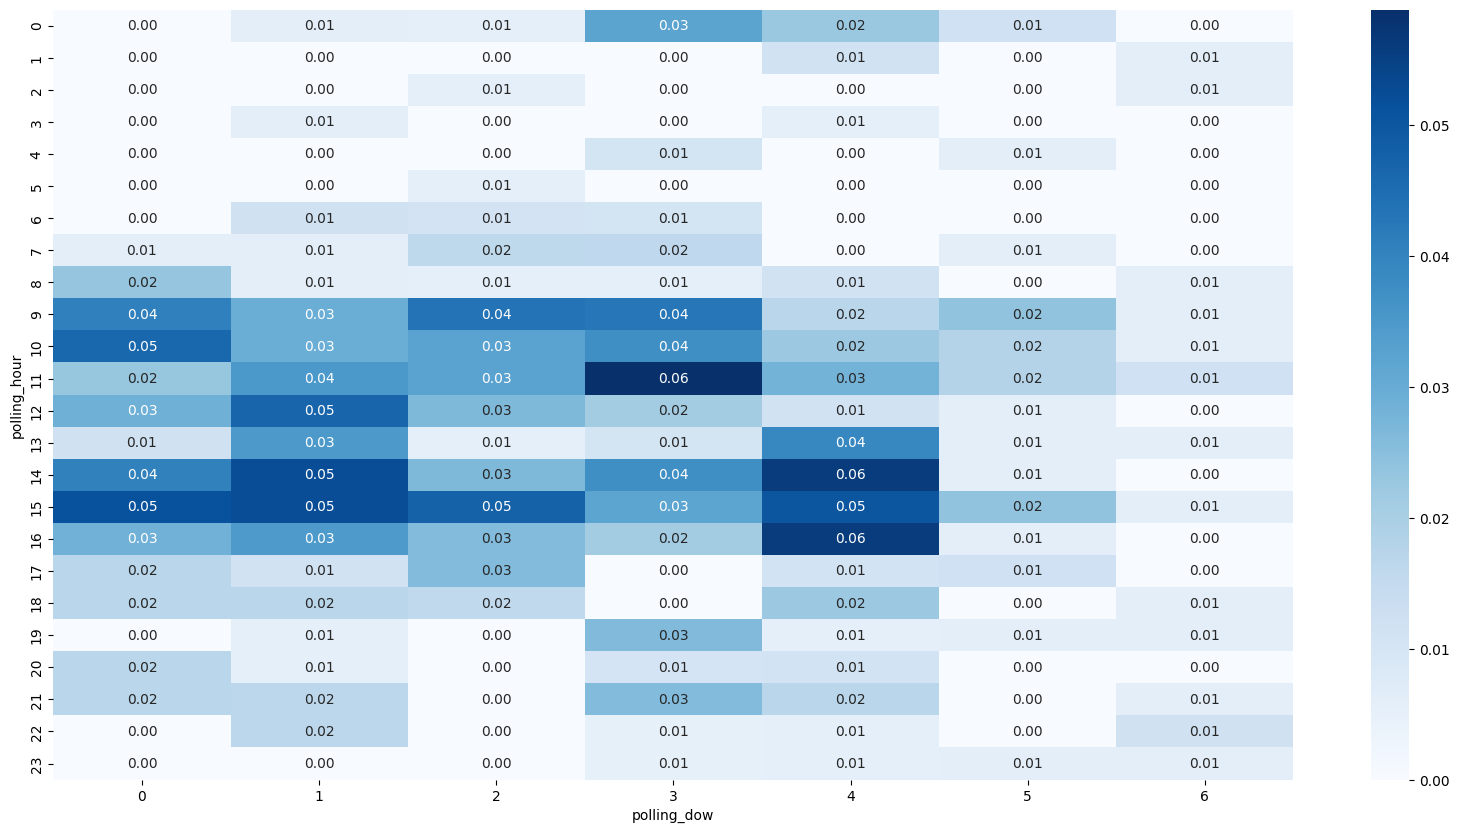

In [35]:
heatmap = df.groupby(["polling_dow","polling_hour"])["has_booking"].mean().reset_index()

pv = pd.pivot(data=heatmap,index="polling_hour",columns="polling_dow",values="has_booking")

fig,ax = plt.subplots(figsize=(20,10))
sns.heatmap(pv,annot=True,fmt=".2f",cmap="Blues")

<Axes: xlabel='polling_hour', ylabel='has_booking'>

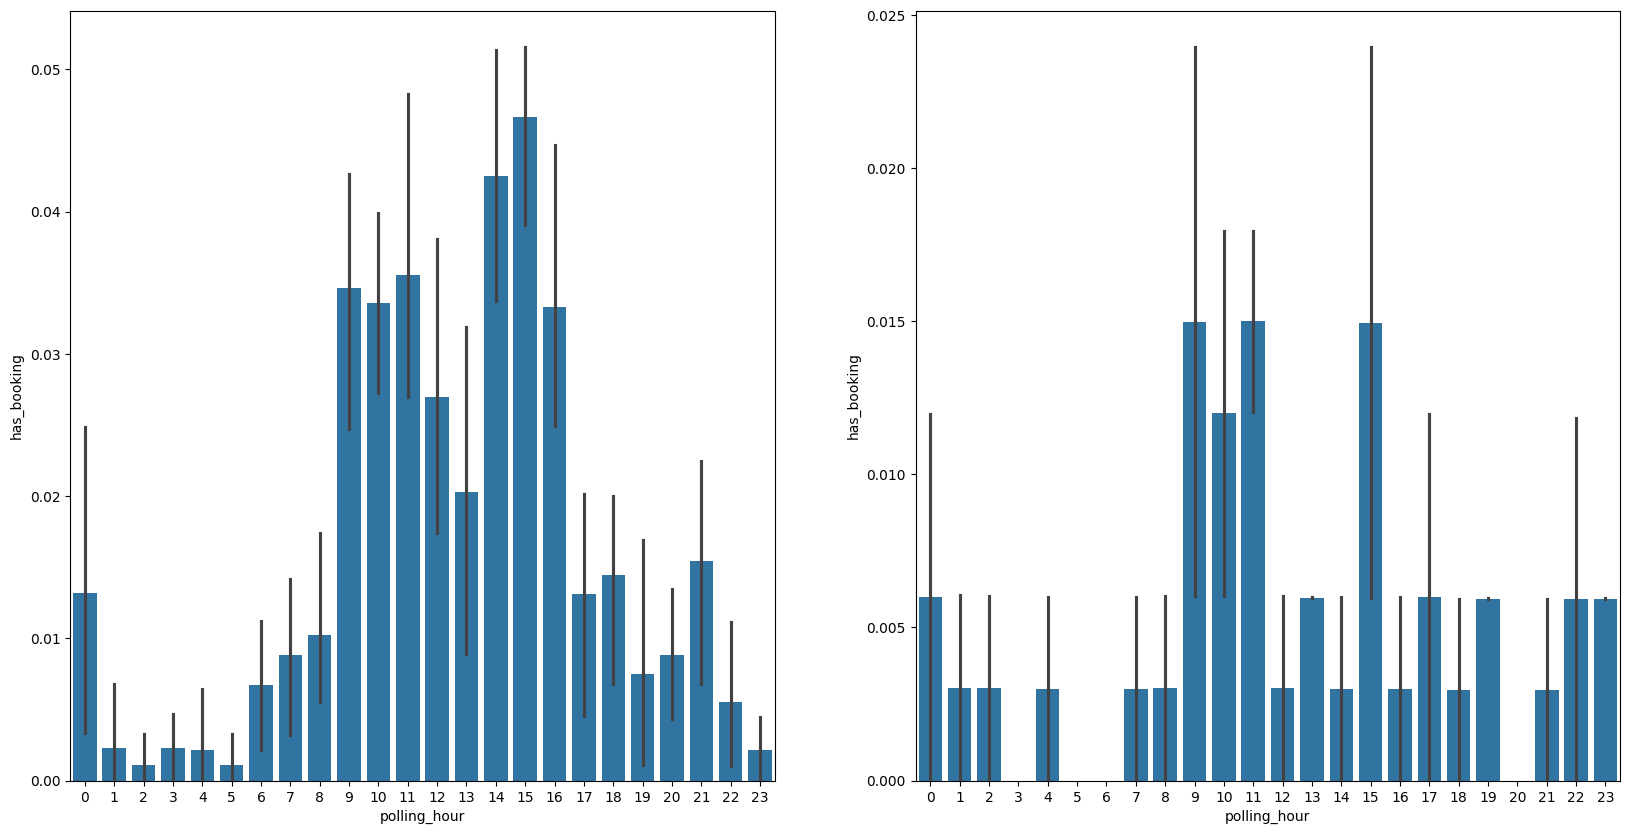

In [36]:
weekday_hour = df.loc[df["polling_dow"].isin([0,1,2,3,4])].groupby(["polling_dow","polling_hour"])["has_booking"].mean().reset_index()
fig,axes = plt.subplots(1,2,figsize=(20,10))
sns.barplot(data=weekday_hour,x="polling_hour",y="has_booking",ax=axes[0])
weekend_hour = df.loc[df["polling_dow"].isin([5,6])].groupby(["polling_dow","polling_hour"])["has_booking"].mean().reset_index()
sns.barplot(data=weekend_hour,x="polling_hour",y="has_booking",ax=axes[1])

                  sum  size      mean   logodds
wknd  block                                    
False night(0-5)   20  5329  0.003753 -5.581426
      morn(6-11)  116  5342  0.021715 -3.807811
      mid(12-17)  164  5420  0.030258 -3.467259
      eve(18-23)   49  5497  0.008914 -4.711184
True  night(0-5)    5  1996  0.002505 -5.986954
      morn(6-11)   16  1998  0.008008 -4.819273
      mid(12-17)   12  2009  0.005973 -5.114495
      eve(18-23)    8  2021  0.003958 -5.527940


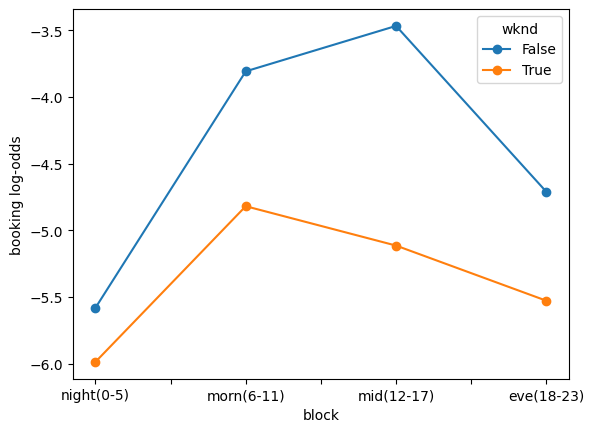

In [37]:
d = df.copy()
d["wknd"]  = d["polling_dow"].isin([5, 6])
d["block"] = pd.cut(d["polling_hour"], [-1, 5, 11, 17, 23],
                    labels=["night(0-5)", "morn(6-11)", "mid(12-17)", "eve(18-23)"])
g = d.groupby(["wknd", "block"], observed=True)["has_booking"].agg(["sum", "size", "mean"])
g["logodds"] = np.log(g["mean"].clip(1e-6, 1-1e-6) / (1 - g["mean"].clip(1e-6, 1-1e-6)))
print(g)                                    
g["logodds"].unstack(0).plot(marker="o")
plt.ylabel("booking log-odds"); plt.show()

<Axes: ylabel='has_booking'>

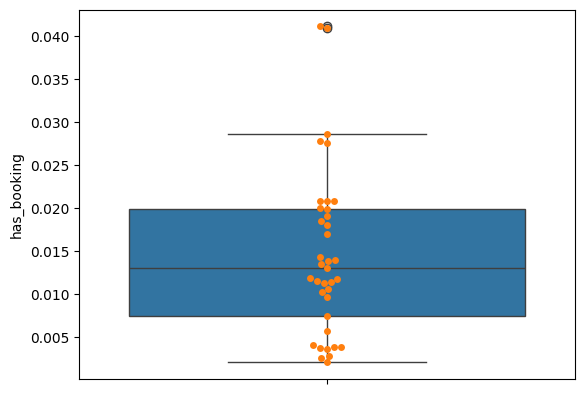

In [38]:
x = df.groupby("username")["has_booking"].mean().reset_index()
sns.boxplot(x,y="has_booking")
sns.swarmplot(x,y="has_booking")

In [39]:
whales,non_whales = get_whale_users()

In [40]:
len(whales)

8

In [41]:
len(non_whales)

5